In [1]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from scipy.interpolate import interp1d
from statsmodels.nonparametric.kernel_regression import KernelReg
from tools import *

In [11]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/KH_RBG_02142026_PF1_P6.csv')
df = clean_and_transpose(df, 31, 129).dropna()
df

Series,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
Time [s],,,,,,,,,,,,,,,,,,,,,
0.000000,0.1766,0.1946,0.1829,0.1852,0.1923,0.2015,0.1833,0.2018,0.1956,0.1980,...,0.1053,0.1025,0.0984,0.0999,0.1038,0.0912,0.1005,0.1004,0.1021,0.1032
0.250028,0.1868,0.1919,0.1861,0.1891,0.1860,0.1846,0.1854,0.1892,0.2026,0.2037,...,0.0997,0.1016,0.0999,0.0993,0.0989,0.1001,0.1003,0.0999,0.1013,0.1024
0.500056,0.1888,0.1951,0.1914,0.1919,0.1923,0.1915,0.1899,0.1920,0.2007,0.2047,...,0.0988,0.1008,0.0990,0.0983,0.0980,0.1004,0.0996,0.0992,0.1007,0.1020
0.750083,0.1954,0.2001,0.1958,0.1984,0.2003,0.2008,0.1962,0.2003,0.2066,0.2088,...,0.0998,0.1020,0.1000,0.0995,0.0990,0.1015,0.1006,0.1001,0.1015,0.1029
1.000083,0.1998,0.2118,0.2010,0.2066,0.2099,0.2130,0.2060,0.2046,0.2054,0.2073,...,0.0997,0.1019,0.1000,0.0990,0.0988,0.1018,0.1007,0.1001,0.1018,0.1030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24.752361,0.3555,0.3280,0.3597,0.3134,0.3238,0.2963,0.3129,0.3075,0.3090,0.3023,...,0.0999,0.1020,0.1000,0.0996,0.0988,0.1018,0.1007,0.1006,0.1019,0.1038
25.002389,0.3562,0.3292,0.3604,0.3143,0.3246,0.2973,0.3143,0.3085,0.3102,0.3037,...,0.1000,0.1022,0.1001,0.0997,0.0990,0.1019,0.1008,0.1009,0.1020,0.1038
25.252417,0.3571,0.3292,0.3614,0.3147,0.3252,0.2977,0.3145,0.3085,0.3113,0.3045,...,0.0995,0.1017,0.0996,0.0991,0.0986,0.1015,0.1003,0.1002,0.1016,0.1033


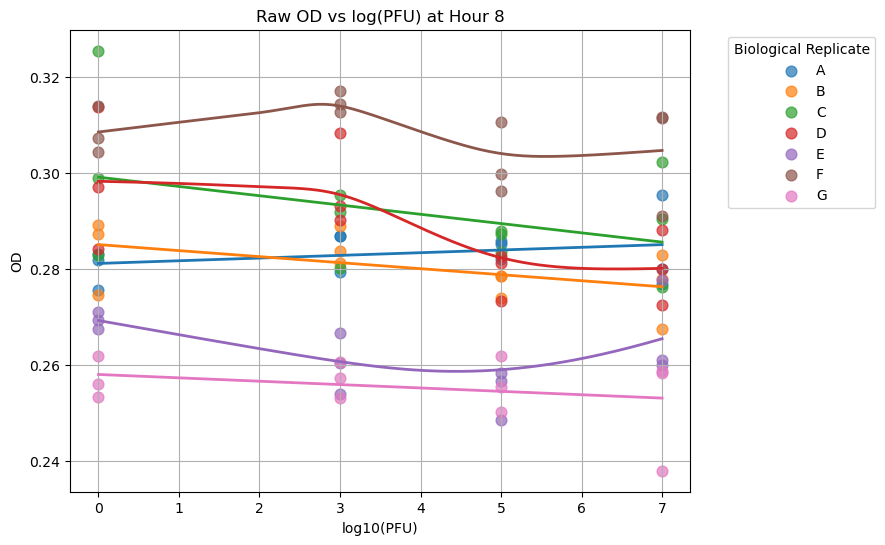

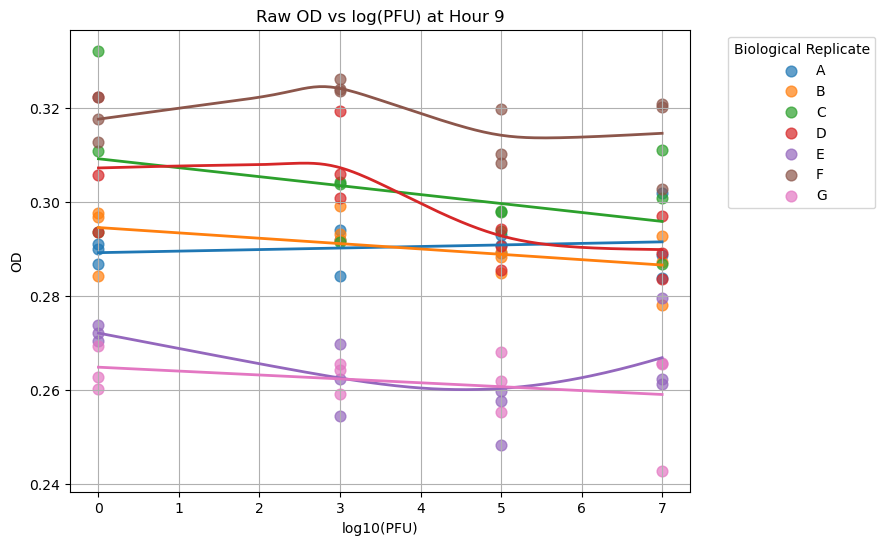

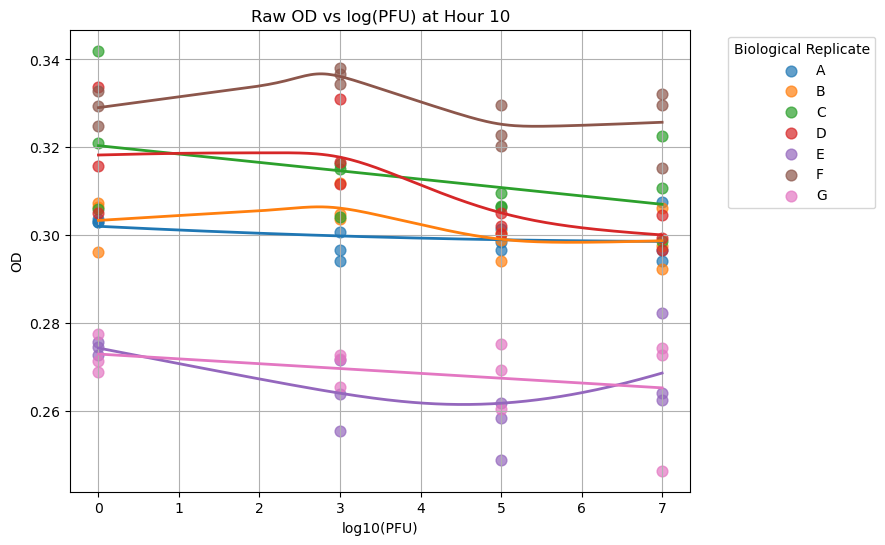

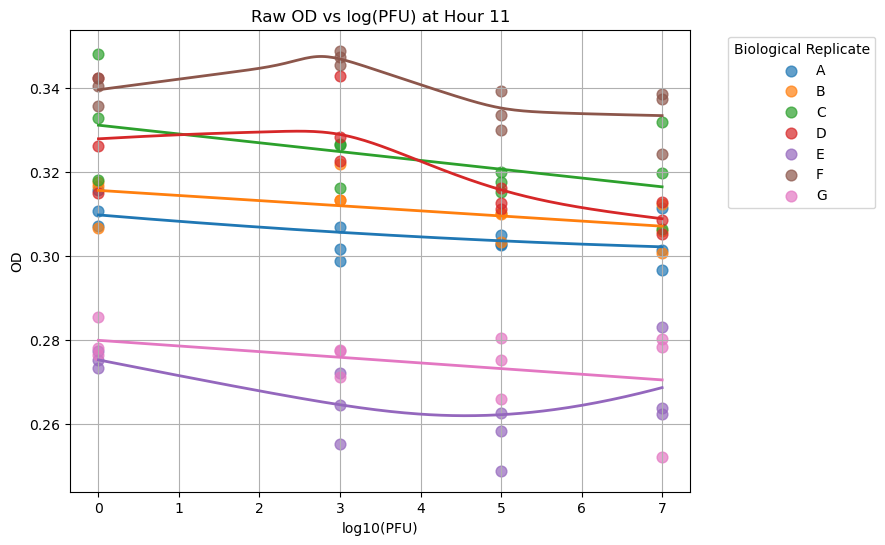

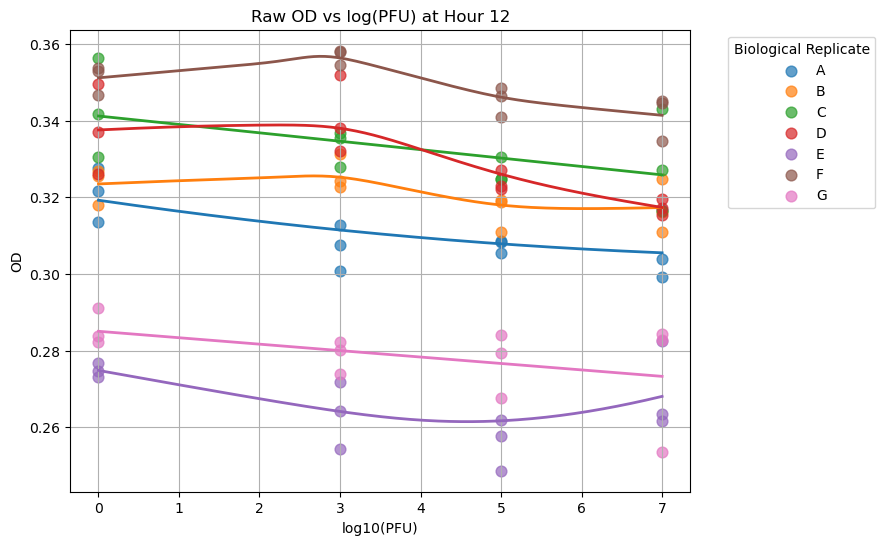

,A,B,C,D,E,F,G
8,3.482412,3.482412,3.482412,3.939698,1.793970,0.175879,3.517588
9,3.517588,3.517588,3.482412,4.080402,1.829146,0.633166,3.517588
10,2.216080,4.010050,3.482412,4.291457,6.859296,0.703518,3.482412
11,2.708543,3.517588,3.482412,4.432161,1.793970,0.351759,3.482412
12,2.567839,4.010050,3.482412,4.643216,1.793970,4.361809,3.482412


In [12]:
df.index = np.round(df.index).astype(int)
df_hourly = df.loc[df.index.isin(range(0, 16))]
df_hourly = df_hourly.groupby(df_hourly.index).first()

x_vals = [0, 3, 5, 7]
bio_reps = list(string.ascii_uppercase)[:7] #A-H

ic50_table = pd.DataFrame(index=range(8,13), columns=bio_reps, dtype=float)

for hour in range(8, 13):
    if hour not in df_hourly.index:
        continue
        
    plt.figure(figsize=(8, 6))

    for letter in bio_reps:
        table = df_hourly.filter(regex = rf'^{letter}')
        if table.empty:
            continue
            
        y_vals = table.loc[hour].values
        
        
        x_repeat = np.repeat(x_vals, 3)
            
        plt.scatter(x_repeat, y_vals, label=letter, s=60, alpha=0.7)
        
       # Fit kernel regression
        kr = KernelReg(endog=y_vals, exog=x_repeat, var_type='c', reg_type='ll')
        
        # Smooth prediction
        x_grid = np.linspace(min(x_repeat), max(x_repeat), 200)
        y_pred_grid, _ = kr.fit(x_grid)
        
        # Half-max from smooth curve
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2
        
        # Find IC50
        idx = np.argmin(np.abs(y_pred_grid - half_max))
        ic50 = x_grid[idx]
        
        # Store in table
        ic50_table.loc[hour, letter] = ic50
        
        # Plot smooth curve
        plt.plot(x_grid, y_pred_grid, lw=2)

        
        
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(f'Raw OD vs log(PFU) at Hour {hour}')
    plt.legend(title='Biological Replicate', bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()
    
ic50_table
        

In [13]:
#interpolate on continous x axis instead 
x_grid = np.linspace(min(x_repeat), max(x_repeat), 200) #smooth x values
# Predict KernelReg on the grid (smooth)
y_pred_grid, y_std_grid = kr.fit(x_grid)

# Compute half max
half_max = (y_vals.max() + y_vals.min()) / 2
# Compute difference between half max and curve
# Find index of smallest difference
idx = np.argmin(np.abs(y_pred_grid - half_max))
ic50 = x_grid[idx]
ic50

np.float64(7.0)

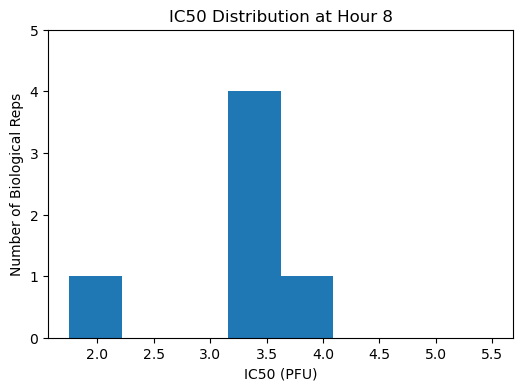

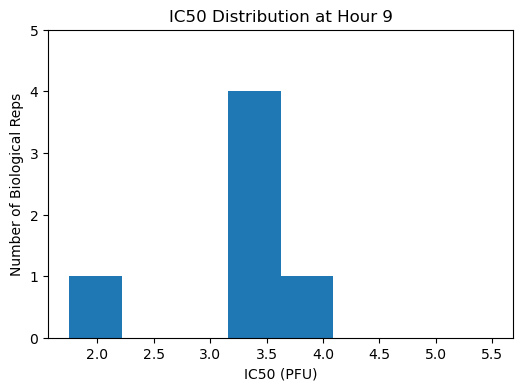

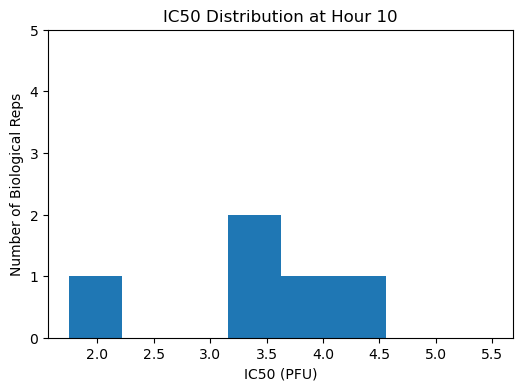

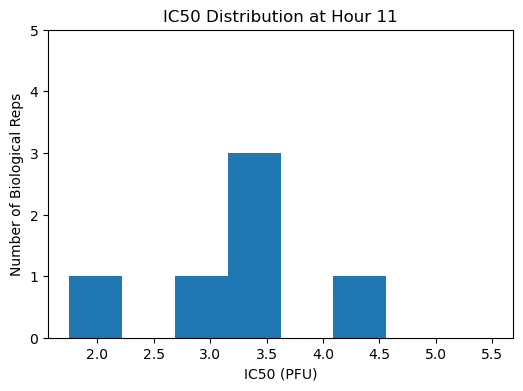

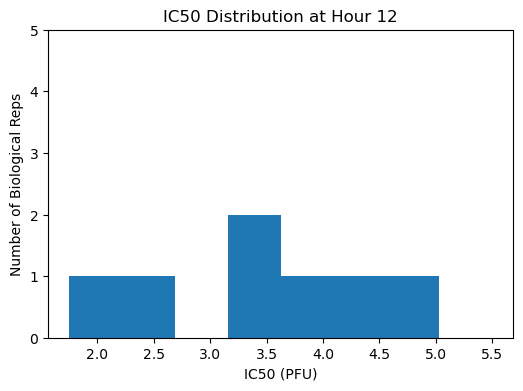

In [18]:
for hour in range(8,13):
    ic50_values = ic50_table.loc[hour].values
    plt.figure(figsize=(6,4))
    plt.hist(ic50_values, bins = 8, range = (1.75, 5.5))
    plt.ylim(0, 5) 
    plt.xlabel('IC50 (PFU)')
    plt.ylabel('Number of Biological Reps')
    plt.title(f'IC50 Distribution at Hour {hour}')